# Plot barrier change panels for every epoch

Plot the trials either side of every barrier change, for every epoch with a populated `HexMazeDecodedPositionHexBarrierChange`
- Plot 1 shows the rat trajectories and neural representations
- Plot 2 shows the same, but colored by old path / new path / other port (and before path divergence, after convergence, and shared path)

`restriction` in the setup cell picks which epochs to run (set it to `{}` for the whole table) 

Every figure is written to `SAVE_DIR`, and `SHOW = False` keeps them off the screen when running the whole table.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from hexmaze import plot_hex_maze, maze_to_barrier_set, maze_to_graph
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock, HexCentroids
from spyglass_hexmaze.hex_maze_decoding import (
    HexMazeDecodedPositionHexBarrierChange, barrier_change_lookups,
    epoch_trials_with_bounds, maze_by_block)

# Pick a rat, session, etc. Empty means every populated epoch
restriction = "nwb_file_name LIKE 'IM-1871_20250803%'" # {} #"nwb_file_name LIKE 'IM-1871_20250803%'"

decode_filter = "spatial_cov < 200 and decode_in_maze == 1 and hex not in [1, 2, 3] and speed > 2"

NONLOCAL_CM = 20            # decodes have to be this far from the rat to count as nonlocal
N_TRIALS = 4                # show this many trials before/after the barrier change
MAZE_COLOR = "#cfcfcf"    # open hexes in the maze are shown in this color

# Display names for trials before/after a barrier change
BEFORE_NAMES = ["last", "second to last", "third to last", "fourth to last", "fifth to last"]
AFTER_NAMES = ["first", "second", "third", "fourth", "fifth"]

SAVE_DIR = Path("barrier_change_figures")
SAVE_DIR.mkdir(exist_ok=True)
SHOW = True # False when running the whole table, so figures only go to disk
DPI = 150

all_keys = (HexMazeDecodedPositionHexBarrierChange() & restriction).fetch(
    "KEY", order_by="nwb_file_name, epoch")

# Each block paired with the one before it: (block 1, block 2), (block 2, block 3), ...
changes_of = {}
for key in all_keys:
    blocks = list((HexMazeBlock & {k: key[k] for k in ("nwb_file_name", "epoch")}).fetch(
        "block", order_by="block"))
    changes_of[key["decoding_merge_id"]] = list(zip(blocks, blocks[1:]))

# A decode is named by its epoch, plus the head of its merge id (in case an epoch has multiple decodes)
stem_of = {key["decoding_merge_id"]:
           f"{key['nwb_file_name'].replace('_.nwb', '')}_ep{key['epoch']}"
           f"_{str(key['decoding_merge_id'])[:8]}" for key in all_keys}

print(f"{len(all_keys)} decodes, {sum(len(v) for v in changes_of.values())} barrier changes, "
      f"saving to {SAVE_DIR}/")

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-09-18 16:04:43,888][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core 

1 decodes, 4 barrier changes, saving to barrier_change_figures/


## Neural representations around barrier change

Plot `N_TRIALS` trials before and after every barrier change in the epoch, with the barrier that moved in the middle column and outlined on the trials after the change (one row per change).

Rat trajectory in black, neural representation in red

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:590: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "MFC_

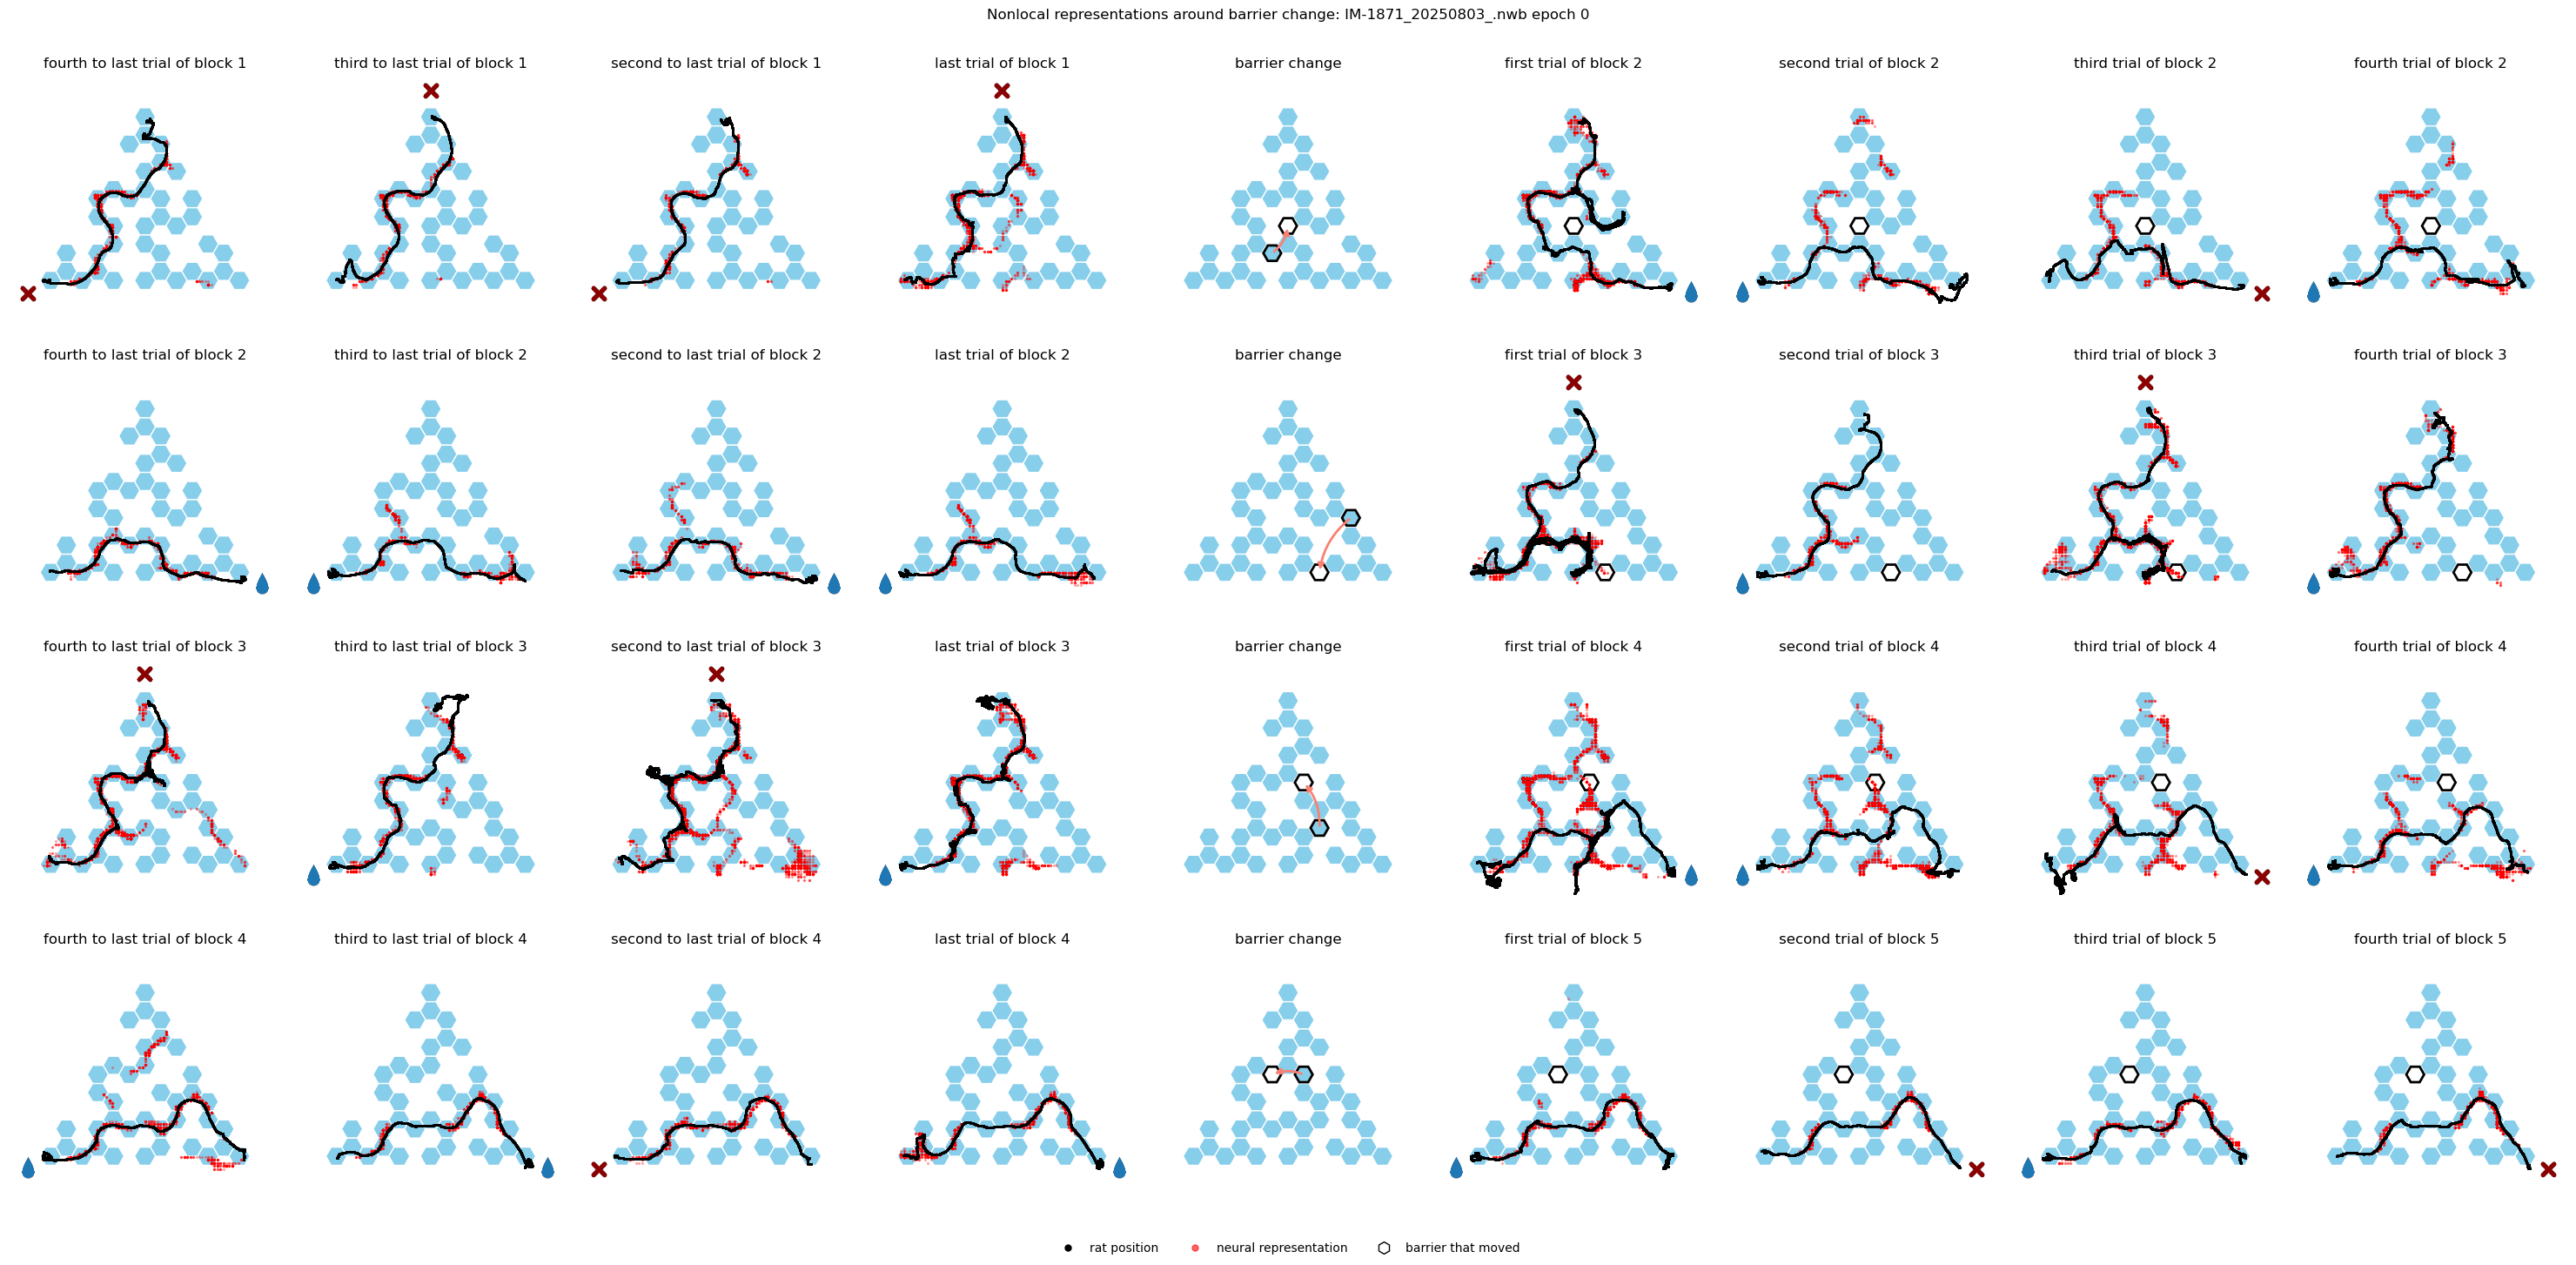

In [2]:
for key in all_keys:
    changes = changes_of[key["decoding_merge_id"]]
    if not changes:
        continue
    df = (HexMazeDecodedPositionHexBarrierChange & key).fetch1_dataframe_with_decode()
    # epoch_trials_with_bounds returns trials in time order
    trials = epoch_trials_with_bounds(key["nwb_file_name"], key["epoch"])
    maze_of_block = maze_by_block(key["nwb_file_name"], key["epoch"])
    centroids = HexCentroids().get_core_hex_centroids_dict_cm(key)

    # Columns for N_TRIALS trials before change, barrier change example maze, N_TRIALS trials after change
    fig, axes = plt.subplots(len(changes), 2 * N_TRIALS + 1,
                             figsize=(3.3 * (2 * N_TRIALS + 1), 3.6 * len(changes)), squeeze=False)

    # Iterate through barrier changes (one row per barrier change)
    for row, (old_block, new_block) in enumerate(changes):
        # Get list of trials directly before and after this barrier change
        before = [t for t in trials if t["block"] == old_block][-N_TRIALS:]
        after = [t for t in trials if t["block"] == new_block][:N_TRIALS]

        # Get the newly open and newly blocked barrier
        # We do this instead of get_barrier_change because IM-1594_20230728 blocks 1->2 moves 2 barriers
        old_barriers = maze_to_barrier_set(maze_of_block[old_block])
        new_barriers = maze_to_barrier_set(maze_of_block[new_block])
        now_open = old_barriers - new_barriers
        now_blocked = new_barriers - old_barriers
        old_barrier, new_barrier = next(iter(now_open)), next(iter(now_blocked))

        ## Panels holds [(column, block, trial, title, hexes to outline)]
        # Outline is None for pre barrier change trials
        panels = [(col, old_block, t, f"{BEFORE_NAMES[len(before) - 1 - col]} trial of "
                   f"block {old_block}", None) for col, t in enumerate(before)]
        # Outline the new barrier in the post barrier change trials
        panels += [(N_TRIALS + 1 + col, new_block, t,
                    f"{AFTER_NAMES[col]} trial of block {new_block}", now_blocked)
                   for col, t in enumerate(after)]

        # Plot each panel
        for col, block, trial, title, outline in panels:
            ax = axes[row][col]
            outline_kwargs = ({"outline_hexes": [outline], "outline_colors": ["black"]}
                              if outline else {})
            # Plot the maze for this trial
            plot_hex_maze(ax=ax, barriers=maze_of_block[block], centroids=centroids,
                          snap_centroids=True, invert_yaxis=True,
                          show_barriers=False, show_hex_labels=False,
                          reward=(trial["end_port"], bool(trial["reward"])), **outline_kwargs)
            # Filter the df to this trial only
            trial_df = df.loc[trial["start_time"]:trial["end_time"]]
            # Only keep decoded samples that pass our filter
            good_decode_samples = trial_df.query(decode_filter) if decode_filter else trial_df
            # Plot decoded positions in red
            ax.scatter(good_decode_samples["decode_position_x"], good_decode_samples["decode_position_y"],
                       s=2, color="red", alpha=0.25, zorder=2)
            # Plot the rat's trajectory on top in black
            ax.scatter(trial_df["position_x"], trial_df["position_y"], s=1, color="k", zorder=3)
            ax.set_title(title, fontsize=12)

        # In between the pre and post barrier change trials, plot a maze showing the barrier change
        # Outline old and new barrier hexes in black and show the arrow from old->new barrier
        ax = axes[row][N_TRIALS]
        plot_hex_maze(ax=ax, barriers=maze_of_block[new_block],
                      old_barrier=old_barrier, new_barrier=new_barrier,
                      show_barrier_change=False, centroids=centroids, snap_centroids=True,
                      invert_yaxis=True, show_barriers=False, show_hex_labels=False,
                      outline_hexes=[now_open, now_blocked],
                      outline_colors=["black", "black"])
        ax.set_title("barrier change", fontsize=12)
        # The pre/post barrier change trial panels leave room for the reward marker, which shrinks their maze, so we
        # match the axis limits of the barrier change panel to them so every maze in the row is drawn at the same size
        ax.set_xlim(axes[row][0].get_xlim())
        ax.set_ylim(axes[row][0].get_ylim())

    fig.legend(handles=[Line2D([], [], color="k", lw=0, marker="o", ms=5, label="rat position"),
                        Line2D([], [], color="red", lw=0, marker="o", ms=5, alpha=0.6,
                               label="neural representation"),
                        Line2D([], [], color="k", lw=0, marker="h", mfc="none", ms=10,
                               label="barrier that moved")],
               loc="lower center", ncol=3, fontsize=10, frameon=False)
    fig.suptitle(f"Nonlocal representations around barrier change: "
                 f"{key['nwb_file_name']} epoch {key['epoch']}", y=1.0, fontsize=12)
    fig.tight_layout(rect=[0, 0.02, 1, 1])
    # Save figure with descriptive name so we can keep track of params used to generate it
    fig.savefig(SAVE_DIR / f"{stem_of[key['decoding_merge_id']]}_representation.png",
                dpi=DPI, bbox_inches="tight")
    if SHOW:
        plt.show()
    else:
        plt.close(fig)

## Neural representations around barrier change (colored by what they represent)

Plot `N_TRIALS` trials before and after every barrier change in the epoch, with the barrier that moved in the middle column and outlined on the trials after the change (one row per change).

Rat trajectory in black, neural representation in orange for old path, green for new path, purple for other port

[2026-09-18 16:09:08,011][WARNING]: Skipped checksum for file with hash: 51b16b98-2019-3e5e-da95-1c57d084f118, and path: /stelmo/nwb/analysis/IM-1871_20250803/IM-1871_20250803_485CGAGEPP.nwb
[2026-09-18 16:09:08,022][WARNING]: Skipped checksum for file with hash: 51b16b98-2019-3e5e-da95-1c57d084f118, and path: /stelmo/nwb/analysis/IM-1871_20250803/IM-1871_20250803_485CGAGEPP.nwb


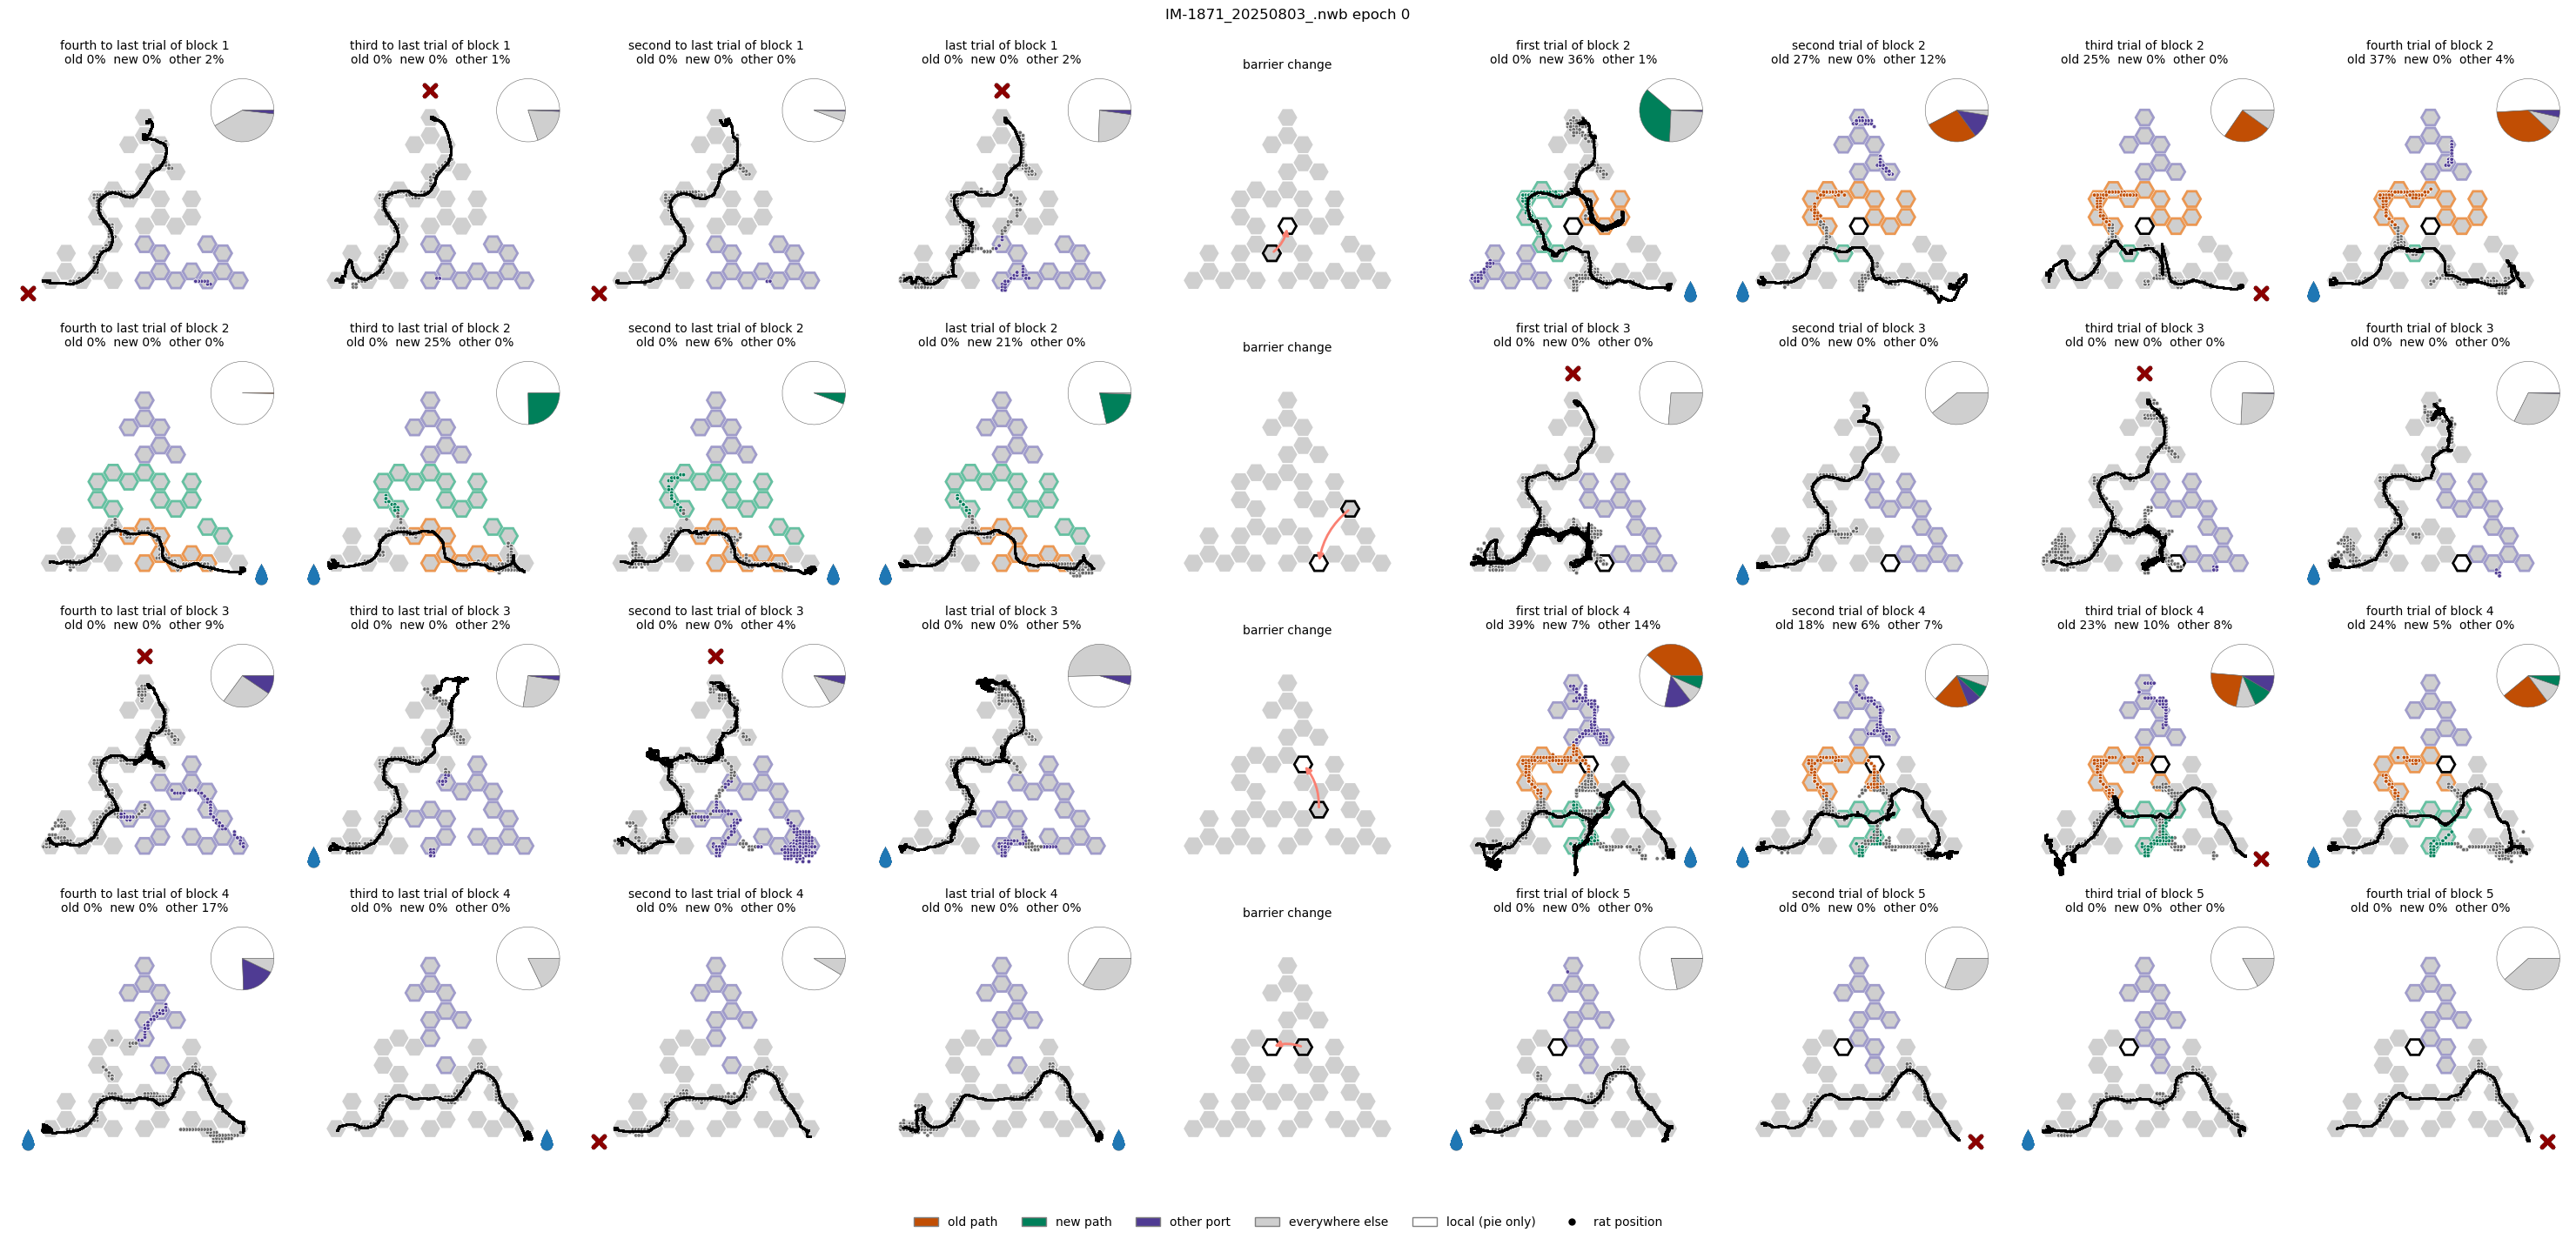

In [ ]:
## The maze stays one flat grey and the class of each hex shows only at its border, so nothing
## on the maze competes with the samples. Outline colors are a paler version of the dot colors
ROUTE_OUTLINES = {"old_path": "#eb9752", "new_path": "#66c0a1", "other": "#a09cca"}
ROUTE_COLORS = {"old_path": "#c14e04", "new_path": "#00805a", "other": "#4f3b93"}
REST_COLOR = MAZE_COLOR     # everything else: the stem either side of the change, shared, local
REST_DOT_COLOR = "#666666"  # its samples, darker than the maze the way the route colors are
                            # darker than their outlines
ROUTE_LABELS = {"old_path": "old path", "new_path": "new path", "other": "other port"}
PIE_COLORS = {**ROUTE_COLORS, "local": "white"}

# True if we want to include hexes hanging off of the optimal routes in the hex classes for old/new path etc,
# false if we want to count optimal routes only (and then everything else is "other")
# NOTE when using "wide", "other" always means the other port. When we switch to strict, "other" also includes
# dead ends etc when using my table as written. So I am gonna fix that bc I want a real "other port" category.
# But your percentages will be weird with "other" if you use strict for now
USE_WIDE_HEX_CLASSES = True

for key in all_keys:
    changes = changes_of[key["decoding_merge_id"]]
    if not changes:
        continue
    df = (HexMazeDecodedPositionHexBarrierChange & key).fetch1_dataframe_with_decode()
    # epoch_trials_with_bounds returns trials in time order
    trials = epoch_trials_with_bounds(key["nwb_file_name"], key["epoch"])
    maze_of_block = maze_by_block(key["nwb_file_name"], key["epoch"])
    centroids = HexCentroids().get_core_hex_centroids_dict_cm(key)

    # Columns for N_TRIALS trials before change, barrier change example maze, N_TRIALS trials after change
    fig, axes = plt.subplots(len(changes), 2 * N_TRIALS + 1,
                             figsize=(3.3 * (2 * N_TRIALS + 1), 3.6 * len(changes)), squeeze=False)

    # Iterate through barrier changes (one row per barrier change)
    for row, (old_block, new_block) in enumerate(changes):
        # Get list of trials directly before and after this barrier change
        before = [t for t in trials if t["block"] == old_block][-N_TRIALS:]
        after = [t for t in trials if t["block"] == new_block][:N_TRIALS]

        # Get the newly open and newly blocked barrier
        # We do this instead of get_barrier_change because IM-1594_20230728 blocks 1->2 moves 2 barriers
        old_barriers = maze_to_barrier_set(maze_of_block[old_block])
        new_barriers = maze_to_barrier_set(maze_of_block[new_block])
        now_open = old_barriers - new_barriers
        now_blocked = new_barriers - old_barriers
        old_barrier, new_barrier = next(iter(now_open)), next(iter(now_blocked))

        ## Panels holds [(column, block, trial, title, hexes to outline)]
        # Outline is None for pre barrier change trials
        panels = [(col, old_block, t, f"{BEFORE_NAMES[len(before) - 1 - col]} trial of "
                   f"block {old_block}", None) for col, t in enumerate(before)]
        # Outline the new barrier in the post barrier change trials
        panels += [(N_TRIALS + 1 + col, new_block, t,
                    f"{AFTER_NAMES[col]} trial of block {new_block}", now_blocked)
                   for col, t in enumerate(after)]

        # Plot each panel
        for col, block, trial, title, outline in panels:
            ax = axes[row][col]
            # Filter the df to this trial only
            trial_df = df.loc[trial["start_time"]:trial["end_time"]]
            # Only keep decoded samples that pass our filter
            good_decode_samples = trial_df.query(decode_filter) if decode_filter else trial_df

            # Get the hexes of each class based on this trial's start and end port
            # The classes belong to the barrier change, so the trials directly before and after it use the same lookup
            by_class, hex_classes = {}, {}
            if trial["start_port"] != "None":
                strict_classes, wide_classes, _ = barrier_change_lookups(maze_of_block[old_block],
                                                                         maze_of_block[new_block],
                                                                         trial["start_port"], trial["end_port"])
                # NOTE here I am using the "wide" classes that include hexes hanging off of the optimal
                # route instead of just the optimal route itself, but we could instead use strict
                hex_classes = wide_classes if USE_WIDE_HEX_CLASSES else strict_classes
                by_class = {route_class: {hex_id for hex_id, hex_class in hex_classes.items()
                                          if hex_class == route_class and hex_id != -100}
                            for route_class in ROUTE_COLORS}

            # Classify each decoded sample by the hex it landed on, and call it local if it is
            # close to the rat. We do this instead of using the stored class column because that
            # column is relative to each block's own change, so on the trials before this change
            # it describes the previous one
            open_hexes = set(maze_to_graph(maze_of_block[block]))
            if hex_classes:
                decoded_hex_class = good_decode_samples["decode_hex_any"].map(hex_classes).fillna("barrier")
                sample_class = np.where(good_decode_samples["decode_distance"].abs() < NONLOCAL_CM,
                                        "local", decoded_hex_class)
            else:
                sample_class = "None"
            good_decode_samples = good_decode_samples.assign(decode_class=sample_class)

            # One outline group per class, plus the barrier that just arrived
            # A class can include a hex that is a barrier in the maze we are drawing, so keep only open hexes
            outline_sets, outline_colors = [], []
            for class_name, hexes in by_class.items():
                if hexes & open_hexes:
                    outline_sets.append(hexes & open_hexes)
                    outline_colors.append(ROUTE_OUTLINES[class_name])
            if outline:
                outline_sets.append(outline)
                outline_colors.append("black")
            outline_kwargs = ({"outline_hexes": outline_sets, "outline_colors": outline_colors}
                              if outline_sets else {})
            # Plot the maze for this trial, flat grey with the class showing only at the hex borders
            plot_hex_maze(ax=ax, barriers=maze_of_block[block], centroids=centroids,
                          snap_centroids=True, invert_yaxis=True,
                          show_barriers=False, show_hex_labels=False,
                          reward=(trial["end_port"], bool(trial["reward"])),
                          highlight_hexes=[open_hexes], highlight_colors=[MAZE_COLOR],
                          **outline_kwargs)
            # Plot decoded positions colored by class, with a white edge so they stay visible
            ax.scatter(good_decode_samples["decode_position_x"], good_decode_samples["decode_position_y"],
                       s=10, alpha=0.9, edgecolors="w", linewidths=0.4, zorder=2,
                       c=good_decode_samples["decode_class"].map(ROUTE_COLORS).fillna(REST_DOT_COLOR))
            # Plot the rat's trajectory on top in black
            ax.scatter(trial_df["position_x"], trial_df["position_y"], s=1, color="k", zorder=3)

            # A pie over every sample, with local in white
            # Every class outside the three we care about (old / new / other) shares one wedge 
            class_counts = good_decode_samples["decode_class"].where(
                good_decode_samples["decode_class"].isin(PIE_COLORS), "rest").value_counts()
            pie = ax.inset_axes([0.70, 0.70, 0.32, 0.32])
            if class_counts.sum():
                pie.pie(class_counts,
                        colors=[PIE_COLORS.get(wedge, REST_COLOR) for wedge in class_counts.index],
                        wedgeprops=dict(edgecolor="0.4", linewidth=0.4))
                # Put the percentages we care about in the panel title too
                class_pct = 100 * class_counts / class_counts.sum()
                title += (f"\nold {class_pct.get('old_path', 0):.0f}%  "
                          f"new {class_pct.get('new_path', 0):.0f}%  "
                          f"other {class_pct.get('other', 0):.0f}%")
            else:
                pie.axis("off")
            ax.set_title(title, fontsize=10)

        # In between the pre and post barrier change trials, plot a maze showing the barrier change
        # Outline old and new barrier hexes in black and show the arrow from old->new barrier
        ax = axes[row][N_TRIALS]
        plot_hex_maze(ax=ax, barriers=maze_of_block[new_block],
                      old_barrier=old_barrier, new_barrier=new_barrier,
                      show_barrier_change=False, centroids=centroids, snap_centroids=True,
                      invert_yaxis=True, show_barriers=False, show_hex_labels=False,
                      highlight_hexes=[set(maze_to_graph(maze_of_block[new_block]))],
                      highlight_colors=[MAZE_COLOR],
                      outline_hexes=[now_open, now_blocked],
                      outline_colors=["black", "black"])
        ax.set_title("barrier change", fontsize=10)
        # The pre/post barrier change trial panels leave room for the reward marker, which shrinks their maze, so we
        # match the axis limits of the barrier change panel to them so every maze in the row is drawn at the same size
        ax.set_xlim(axes[row][0].get_xlim())
        ax.set_ylim(axes[row][0].get_ylim())

    fig.legend(handles=[Patch(facecolor=ROUTE_COLORS[c], edgecolor="0.5", label=ROUTE_LABELS[c])
                        for c in ROUTE_COLORS]
                       + [Patch(facecolor=REST_COLOR, edgecolor="0.5", label="everywhere else"),
                          Patch(facecolor="white", edgecolor="0.5", label="local (pie only)"),
                          Line2D([], [], color="k", lw=0, marker="o", ms=5, label="rat position")],
               loc="lower center", ncol=6, fontsize=10, frameon=False)
    fig.suptitle(f"{key['nwb_file_name']} epoch {key['epoch']}", fontsize=12)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    # Save figure with descriptive name so we can keep track of params used to generate it
    fig.savefig(SAVE_DIR / f"{stem_of[key['decoding_merge_id']]}_by_class.png",
                dpi=DPI, bbox_inches="tight")
    if SHOW:
        plt.show()
    else:
        plt.close(fig)